In [2]:
import urllib.request
import zipfile

url = "https://storage.googleapis.com/public-datasets-lila/snapshotserengeti-v-2-0/SnapshotSerengeti_S1-11_v2_1.csv.zip"

urllib.request.urlretrieve(url, "serengeti.zip")

with zipfile.ZipFile("serengeti.zip") as z:
    z.extractall("./json_files")

print("Done")

Done


In [10]:
import pandas as pd

# Load both CSVs - update filenames as needed
annotations = pd.read_csv("./json_files/SnapshotSerengeti_v2_1_annotations.csv", low_memory=False)
images   = pd.read_csv("./json_files/SnapshotSerengeti_v2_1_images.csv")  # second CSV with image_path_rel

print(annotations.columns)
print(images.columns)

Index(['Unnamed: 0', 'capture_id', 'season', 'site', 'roll', 'capture',
       'capture_date_local', 'capture_time_local', 'subject_id',
       'question__species', 'question__count_max', 'question__count_median',
       'question__count_min', 'question__standing', 'question__resting',
       'question__moving', 'question__eating', 'question__interacting',
       'question__young_present', 'p_users_identified_this_species',
       'pielous_evenness_index', 'question__horns_visible'],
      dtype='object')
Index(['Unnamed: 0', 'capture_id', 'image_rank_in_capture', 'image_path_rel'], dtype='object')


In [11]:
behaviors = ["question__standing", "question__eating", "question__moving",
             "question__resting", "question__interacting", "question__young_present"]

for b in behaviors:
    print(f"\n{b}")
    print(annotations[b].describe())
    print(f"nulls: {annotations[b].isna().sum()}")


question__standing
count    695322.000000
mean          0.466217
std           0.337953
min           0.000000
25%           0.170000
50%           0.410000
75%           0.800000
max           1.000000
Name: question__standing, dtype: float64
nulls: 1992755

question__eating
count    695322.000000
mean          0.319282
std           0.379370
min           0.000000
25%           0.000000
50%           0.100000
75%           0.700000
max           1.000000
Name: question__eating, dtype: float64
nulls: 1992755

question__moving
count    695322.000000
mean          0.421533
std           0.384615
min           0.000000
25%           0.050000
50%           0.300000
75%           0.820000
max           1.000000
Name: question__moving, dtype: float64
nulls: 1992755

question__resting
count    695322.000000
mean          0.094808
std           0.235058
min           0.000000
25%           0.000000
50%           0.000000
75%           0.060000
max           1.000000
Name: question__resting, 

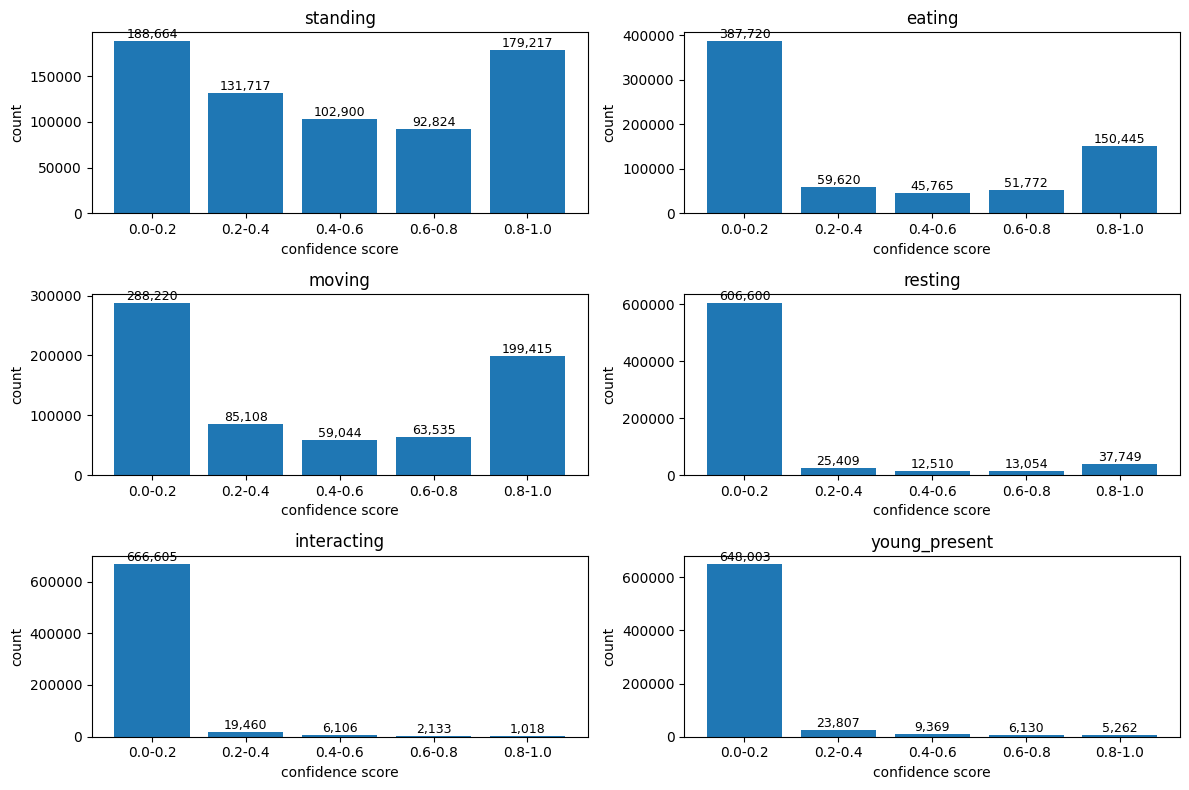

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

#behaviors = ["question__standing", "question__eating", "question__moving", "question__resting"]
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for ax, b in zip(axes.flatten(), behaviors):
    counts = pd.cut(annotations[b].dropna(), bins=bins, labels=labels, right=False).value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(b.replace("question__", ""))
    ax.set_xlabel("confidence score")
    ax.set_ylabel("count")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("behavior_distributions.png")
plt.show()

In [13]:
print(annotations["question__count_min"].dtype)
print(annotations["question__count_min"].apply(type).value_counts())
print(annotations["question__count_min"].unique()[:20])

object
<class 'float'>    1999671
<class 'str'>       688406
Name: question__count_min, dtype: int64
['1' nan '2' '6' '3' '4' '5' '8' '7' '11-50' '10' '9' '51+']


In [14]:
# drop ambiguous and nan
annotations = annotations[~annotations["question__count_min"].isin(["11-50", "51+"])]
annotations = annotations.dropna(subset=["question__count_min"])

# standardize to int
annotations["question__count_min"] = annotations["question__count_min"].astype(float).astype(int)

print(annotations["question__count_min"].value_counts().sort_index())

1     407013
2     107242
3      58698
4      33937
5      21819
6      14083
7       9051
8       6790
9       4112
10      5894
Name: question__count_min, dtype: int64


In [6]:
annotations.head()

,Unnamed: 0,capture_id,season,site,roll,capture,capture_date_local,capture_time_local,subject_id,question__species,...,question__count_min,question__standing,question__resting,question__moving,question__eating,question__interacting,question__young_present,p_users_identified_this_species,pielous_evenness_index,question__horns_visible
0,0,SER_S1#B04#1#1,S1,B04,1,1,2010-07-18,16:26:14,ASG0002kjh,human,...,1,0.62,0.06,0.00,0.00,0.50,0.0,1.00,0.00,NaN
1,1,SER_S1#B04#1#2,S1,B04,1,2,2010-07-18,16:26:30,ASG0002kji,human,...,1,0.10,0.62,0.00,0.05,0.33,0.0,1.00,0.00,NaN
5,5,SER_S1#B04#1#6,S1,B04,1,6,2010-07-24,08:20:10,ASG0002kjm,gazelleGrants,...,1,0.00,0.00,1.00,0.00,0.00,0.0,0.52,0.70,NaN
6,6,SER_S1#B04#1#7,S1,B04,1,7,2010-07-24,10:14:32,ASG0002kjn,reedbuck,...,1,0.83,0.00,0.17,0.00,0.00,0.0,0.33,0.96,NaN
7,7,SER_S1#B04#1#8,S1,B04,1,8,2010-07-30,03:59:42,ASG0002kjo,dikDik,...,1,0.81,0.00,0.19,0.00,0.00,0.0,0.84,0.48,NaN


In [7]:
images.head()

,Unnamed: 0,capture_id,image_rank_in_capture,image_path_rel
0,0,SER_S1#B04#1#1,1,S1/B04/B04_R1/S1_B04_R1_PICT0001.JPG
1,1,SER_S1#B04#1#2,1,S1/B04/B04_R1/S1_B04_R1_PICT0002.JPG
2,2,SER_S1#B04#1#3,1,S1/B04/B04_R1/S1_B04_R1_PICT0003.JPG
3,3,SER_S1#B04#1#4,1,S1/B04/B04_R1/S1_B04_R1_PICT0004.JPG
4,4,SER_S1#B04#1#5,1,S1/B04/B04_R1/S1_B04_R1_PICT0005.JPG


In [8]:
print(len(annotations), len(images))

668639 7178440


In [15]:
# Merge on capture_id
df_merged = annotations.merge(images[["capture_id", "image_path_rel"]], on="capture_id", how="inner")
print(len(df_merged))

# Filter count_min == 1
df_filtered = df_merged[df_merged["question__count_min"] <= 3]
print(len(df_filtered))

# Behavior columns
#behaviors = ["question__standing", "question__eating", "question__moving", "question__resting"]

HIGH = 0.8
LOW = 0.2
num_samples = 2000

sampled = []
for b in behaviors:
    df_b = df_filtered.dropna(subset=behaviors)  # drop rows where ANY behavior is null
    #pos = df_b[df_b[b] >= HIGH].nlargest(num_samples, b)
    pos = df_b.nlargest(num_samples, b)
    sampled.append(pos)

final = pd.concat(sampled).drop_duplicates(subset="image_path_rel")

# binarize
#for b in behaviors:
#    final[b] = final[b].apply(lambda x: 1 if x >= HIGH else (0 if x <= LOW else None))

print(f"Total captures: {len(final)}\n")
for b in behaviors:
    pos = (final[b] >= HIGH).sum()
    neg = (final[b] <= LOW).sum()
    print(f"{b:<30}  +={pos:>5}  -={neg:>5}")

1756107
1487449
Total captures: 11933

question__standing              += 3079  -= 5535
question__eating                += 2281  -= 8779
question__moving                += 2704  -= 7970
question__resting               += 2209  -= 9441
question__interacting           += 1993  -= 9663
question__young_present         += 2078  -= 9363


In [8]:
final.head()

,Unnamed: 0,capture_id,season,site,roll,capture,capture_date_local,capture_time_local,subject_id,question__species,...,question__standing,question__resting,question__moving,question__eating,question__interacting,question__young_present,p_users_identified_this_species,pielous_evenness_index,question__horns_visible,image_path_rel
8,16,SER_S1#B04#1#17,S1,B04,1,17,2010-08-05,02:24:04,ASG0002kjx,zebra,...,1.0,0.08,0.0,0.0,0.0,0.00,1.00,0.00,NaN,S1/B04/B04_R1/S1_B04_R1_PICT0017.JPG
9,17,SER_S1#B04#1#18,S1,B04,1,18,2010-08-05,02:29:02,ASG0002kjy,zebra,...,1.0,0.00,0.0,0.0,0.0,0.00,1.00,0.00,NaN,S1/B04/B04_R1/S1_B04_R1_PICT0018.JPG
44,43,SER_S1#B05#1#14,S1,B05,1,14,2010-07-28,18:04:14,ASG000000e,impala,...,1.0,0.00,0.0,0.0,0.0,0.08,0.52,0.75,NaN,S1/B05/B05_R1/S1_B05_R1_PICT0026.JPG
45,43,SER_S1#B05#1#14,S1,B05,1,14,2010-07-28,18:04:14,ASG000000e,impala,...,1.0,0.00,0.0,0.0,0.0,0.08,0.52,0.75,NaN,S1/B05/B05_R1/S1_B05_R1_PICT0027.JPG
145,103,SER_S1#B05#3#18,S1,B05,3,18,2010-09-03,16:41:18,ASG0002kla,impala,...,1.0,0.00,0.0,0.0,0.0,0.00,0.65,0.80,NaN,S1/B05/B05_R3/S1_B05_R3_PICT0050.JPG


In [16]:
import os
import h5py
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from google.cloud import storage
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

# ── Config ─────────────────────────────────────────────────────────────────────
DATA_DIR    = "../../../media/Data-10T-1/Bhavesh-project/ser_data_2"
HDF5_PATH   = "../embeddings/ser_data_2_embeddings.h5"
NUM_WORKERS = 8
BEHAVIORS   = behaviors
BASE_PATH   = "snapshotserengeti-unzipped/"

os.makedirs(DATA_DIR, exist_ok=True)

# ── 1. Download ────────────────────────────────────────────────────────────────
bucket = storage.Client.create_anonymous_client().bucket("public-datasets-lila")

def dl(task):
    blob_path, local_path = task
    try:
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        if not os.path.exists(local_path):
            bucket.blob(blob_path).download_to_filename(local_path)
        return True
    except:
        return False

tasks = [
    (BASE_PATH + row["image_path_rel"], os.path.join(DATA_DIR, row["image_path_rel"]))
    for _, row in final.iterrows()
]

print(f"Downloading {len(tasks)} images...")
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
    results = list(tqdm(pool.map(dl, tasks), total=len(tasks)))

print(f"Downloaded: {sum(results)}/{len(tasks)}")

100%|██████████| 11933/11933 [07:47<00:00, 25.53it/s]

Downloaded: 11888/11933


In [18]:
import h5py
import numpy as np
import torch, torchvision
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from tqdm import tqdm

torchvision.disable_beta_transforms_warning()

# ── Config ─────────────────────────────────────────────────────────────────────
DINOV2_MODEL = "facebook/dinov2-large"   # 768-dim, use dinov2-large for 1024-dim
BATCH_SIZE   = 64
#BEHAVIORS    = ["question__standing", "question__eating", "question__moving", "question__resting"]
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# ── Extract embeddings in batches ──────────────────────────────────────────────
image_paths = final["image_path_rel"].tolist()
labels      = final[BEHAVIORS].values.astype("float32")   # shape (N, 6)
N           = len(image_paths)
EMB_DIM     = 1024

In [19]:
# ── Load model ─────────────────────────────────────────────────────────────────
processor = AutoImageProcessor.from_pretrained(DINOV2_MODEL)
model     = AutoModel.from_pretrained(DINOV2_MODEL).to(DEVICE).eval()

with h5py.File(HDF5_PATH, "w") as hf:
    emb_ds   = hf.create_dataset("embeddings",  (N, EMB_DIM), dtype="float32")
    label_ds = hf.create_dataset("labels",      (N, len(BEHAVIORS)),       dtype="float32")
    path_ds  = hf.create_dataset("image_paths", (N,),         dtype=h5py.string_dtype())

    for start in tqdm(range(0, N, BATCH_SIZE), desc="Extracting"):
        end          = min(start + BATCH_SIZE, N)
        batch_paths  = image_paths[start:end]
        batch_labels = labels[start:end]

        images, valid_idx = [], []
        for j, p in enumerate(batch_paths):
            try:
                images.append(Image.open(os.path.join(DATA_DIR, p)).convert("RGB"))
                valid_idx.append(j)
            except:
                pass

        if not images:
            continue

        inputs = processor(images=images, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            emb = model(**inputs).last_hidden_state[:, 0, :].cpu().numpy()

        for k, j in enumerate(valid_idx):
            idx = start + j
            emb_ds[idx]   = emb[k]
            label_ds[idx] = batch_labels[j]
            path_ds[idx]  = batch_paths[j]

print(f"Done — saved {N} embeddings to {HDF5_PATH}")

Extracting: 100%|██████████| 187/187 [09:47<00:00,  3.14s/it]

Done — saved 11933 embeddings to ../embeddings/ser_data_2_embeddings.h5


In [20]:
from itertools import combinations

pos_threshold = 0.5

Y_hard = (labels >= pos_threshold).astype(int)
names  = [b.replace("question__", "") for b in BEHAVIORS]

print("Single behavior counts:")
for i, name in enumerate(names):
    print(f"  {name:<10} {Y_hard[:, i].sum():>6}")

print("\nCo-occurrence counts:")
for i, j in combinations(range(len(names)), 2):
    count = ((Y_hard[:, i] == 1) & (Y_hard[:, j] == 1)).sum()
    print(f"  {names[i]:<10} + {names[j]:<10}  {count:>6}")

print("\nTriple co-occurrence counts:")
for i, j, k in combinations(range(len(names)), 3):
    count = ((Y_hard[:, i] == 1) & (Y_hard[:, j] == 1) & (Y_hard[:, k] == 1)).sum()
    print(f"  {names[i]:<10} + {names[j]:<10} + {names[k]:<10}  {count:>6}")

Single behavior counts:
  standing     4497
  eating       2610
  moving       3119
  resting      2366
  interacting   2053
  young_present   2188

Co-occurrence counts:
  standing   + eating         535
  standing   + moving         295
  standing   + resting        570
  standing   + interacting     909
  standing   + young_present    1263
  eating     + moving         195
  eating     + resting         84
  eating     + interacting     172
  eating     + young_present     371
  moving     + resting         67
  moving     + interacting     111
  moving     + young_present     908
  resting    + interacting     102
  resting    + young_present     356
  interacting + young_present     170

Triple co-occurrence counts:
  standing   + eating     + moving          62
  standing   + eating     + resting         54
  standing   + eating     + interacting     120
  standing   + eating     + young_present     240
  standing   + moving     + resting         22
  standing   + moving     + in

In [21]:
import h5py
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

BEHAVIORS     = ["question__standing", "question__eating", "question__moving", "question__resting", "question__interacting"]
BINARY_LABEL  = "question__young_present"
ALL_COLS      = BEHAVIORS + [BINARY_LABEL]

# ── Load ───────────────────────────────────────────────────────────────────────
with h5py.File(HDF5_PATH, "r") as hf:
    X      = hf["embeddings"][:]
    labels = hf["labels"][:]        # (N, 6) — 5 behaviors + young_present

valid  = X.sum(axis=1) != 0
X      = X[valid]
labels = labels[valid]

# ── Prepare multiclass labels (argmax of 5 behaviors) ─────────────────────────
Y_behaviors   = labels[:, :5]                        # standing, eating, moving, resting, interacting
Y_multiclass  = np.argmax(Y_behaviors, axis=1)       # 0-4, always picks strongest behavior
Y_binary      = (labels[:, 5] >= 0.8).astype(int)   # young_present hard label

X_train, X_test, Y_mc_train, Y_mc_test, Y_bin_train, Y_bin_test = train_test_split(
    X, Y_multiclass, Y_binary, test_size=0.2, random_state=42
)

# ── 1. Multiclass XGBoost ──────────────────────────────────────────────────────
print("Training multiclass behavior classifier...")
mc_model = XGBClassifier(
    objective="multi:softprob",
    subsample=0.8,
    num_class=5,
    n_estimators=500,
    min_child_weight=0.3,
    colsample_bytree=1,
    learning_rate=1,
    max_depth=6,
    verbosity=0,
)
mc_model.fit(X_train, Y_mc_train)

Y_mc_pred = mc_model.predict(X_test)
print("\n── Behavior (multiclass) ──")
print(classification_report(Y_mc_test, Y_mc_pred,
      target_names=[b.replace("question__", "") for b in BEHAVIORS]))

# ── 2. Binary XGBoost for young_present ───────────────────────────────────────
print("Training binary young_present classifier...")
pos_weight   = (~Y_bin_train.astype(bool)).sum() / Y_bin_train.sum()   # auto class weight
bin_model = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=pos_weight,
    subsample=0.6,
    n_estimators=300,
    min_child_weight=1,
    colsample_bytree=0.6,
    learning_rate=0.2,
    max_depth=10,
    verbosity=0,
)
bin_model.fit(X_train, Y_bin_train)

Y_bin_pred      = bin_model.predict(X_test)
Y_bin_pred_prob = bin_model.predict_proba(X_test)[:, 1]
print("\n── young_present (binary) ──")
print(f"AUC:  {roc_auc_score(Y_bin_test, Y_bin_pred_prob):.3f}")
print(classification_report(Y_bin_test, Y_bin_pred))

Training multiclass behavior classifier...

── Behavior (multiclass) ──
              precision    recall  f1-score   support

    standing       0.89      0.89      0.89       607
      eating       0.87      0.90      0.89       448
      moving       0.87      0.87      0.87       511
     resting       0.91      0.93      0.92       414
 interacting       0.87      0.80      0.83       370

    accuracy                           0.88      2350
   macro avg       0.88      0.88      0.88      2350
weighted avg       0.88      0.88      0.88      2350

Training binary young_present classifier...

── young_present (binary) ──
AUC:  0.986
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1954
           1       0.90      0.83      0.86       396

    accuracy                           0.96      2350
   macro avg       0.93      0.91      0.92      2350
weighted avg       0.95      0.96      0.95      2350



In [17]:
from sklearn.model_selection import RandomizedSearchCV

# ── Hyperparameter grid ────────────────────────────────────────────────────────
param_grid = {
    "n_estimators":  [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth":     [6, 8, 10],
    "subsample":     [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

# ── Multiclass ─────────────────────────────────────────────────────────────────
print("Tuning multiclass model...")
mc_search = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", num_class=5, verbosity=0),
    param_distributions=param_grid,
    n_iter=5,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

mc_search.fit(X_train, Y_mc_train)
print(f"Best params: {mc_search.best_params_}")
print(f"Best f1_macro: {mc_search.best_score_:.3f}")

mc_model  = mc_search.best_estimator_
Y_mc_pred = mc_model.predict(X_test)
print("\n── Behavior (multiclass) ──")
print(classification_report(Y_mc_test, Y_mc_pred,
      target_names=[b.replace("question__", "") for b in BEHAVIORS]))

# ── Binary ─────────────────────────────────────────────────────────────────────
print("\nTuning binary young_present model...")
pos_weight = (~Y_bin_train.astype(bool)).sum() / Y_bin_train.sum()

bin_search = RandomizedSearchCV(
    XGBClassifier(objective="binary:logistic", scale_pos_weight=pos_weight, verbosity=0),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
bin_search.fit(X_train, Y_bin_train)
print(f"Best params: {bin_search.best_params_}")
print(f"Best AUC: {bin_search.best_score_:.3f}")

bin_model       = bin_search.best_estimator_
Y_bin_pred      = bin_model.predict(X_test)
Y_bin_pred_prob = bin_model.predict_proba(X_test)[:, 1]
print("\n── young_present (binary) ──")
print(f"AUC:  {roc_auc_score(Y_bin_test, Y_bin_pred_prob):.3f}")
print(classification_report(Y_bin_test, Y_bin_pred))

Tuning multiclass model...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best f1_macro: 0.825

── Behavior (multiclass) ──
              precision    recall  f1-score   support

    standing       0.91      0.92      0.92       287
      eating       0.91      0.93      0.92       226
      moving       0.88      0.88      0.88       276
     resting       0.91      0.98      0.95       187
 interacting       0.93      0.62      0.75        64

    accuracy                           0.91      1040
   macro avg       0.91      0.87      0.88      1040
weighted avg       0.91      0.91      0.90      1040


Tuning binary young_present model...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 

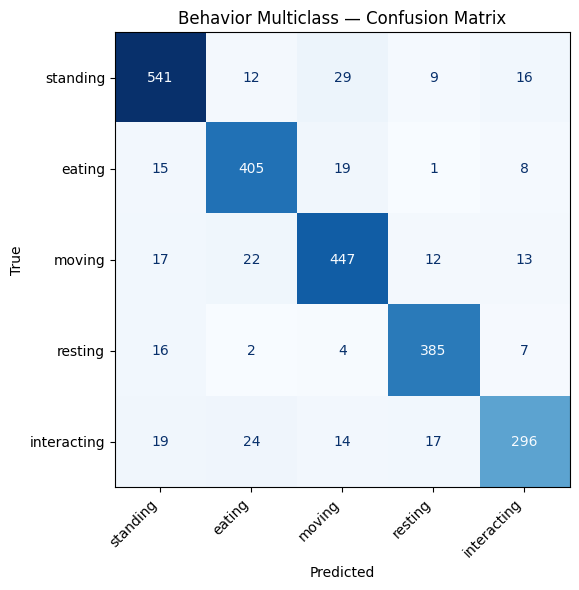

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

behavior_names = [b.replace("question__", "") for b in BEHAVIORS]

cm      = confusion_matrix(Y_mc_test, Y_mc_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=behavior_names)

fig, ax = plt.subplots(figsize=(8, 6))
display.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Behavior Multiclass — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# Classifier Chain method

In [23]:
from sklearn.multioutput import ClassifierChain
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

THRESHOLD = 0.5

# binarize labels for all 5 behaviors (exclude young_present)
Y_hard = (labels[:, :5] >= THRESHOLD).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_hard, test_size=0.2, random_state=42
)

# order: standing(0) → eating(1) → moving(2) → resting(3) → interacting(4)
chain = ClassifierChain(
    LogisticRegression(class_weight="balanced", max_iter=2000, C=1.0),
    order=[0, 1, 2, 3, 4],
    random_state=42
)
chain.fit(X_train, Y_train)

Y_pred_prob = chain.predict_proba(X_test)
Y_pred      = (Y_pred_prob >= THRESHOLD).astype(int)

behavior_names = [b.replace("question__", "") for b in BEHAVIORS]
for i, name in enumerate(behavior_names):
    print(f"\n── {name} ──")
    print(f"AUC:  {roc_auc_score(Y_test[:, i], Y_pred_prob[:, i]):.3f}")
    print(classification_report(Y_test[:, i], Y_pred[:, i]))

all_zero = (Y_pred.sum(axis=1) == 0).sum()
print(f"\nAll-zero predictions: {all_zero} / {len(X_test)} ({100*all_zero/len(X_test):.1f}%)")


── standing ──
AUC:  0.908
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1454
           1       0.77      0.81      0.79       896

    accuracy                           0.83      2350
   macro avg       0.82      0.83      0.83      2350
weighted avg       0.84      0.83      0.84      2350


── eating ──
AUC:  0.935
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1827
           1       0.71      0.83      0.76       523

    accuracy                           0.88      2350
   macro avg       0.83      0.86      0.84      2350
weighted avg       0.89      0.88      0.89      2350


── moving ──
AUC:  0.903
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1762
           1       0.70      0.74      0.72       588

    accuracy                           0.86      2350
   macro avg       0.81      0.82      0.81     

In [24]:
from sklearn.metrics import precision_recall_curve, f1_score

# Dictionary to store the best threshold for each behavior
optimal_thresholds = {}

print("── Optimizing Thresholds (Maximizing F1-Score) ──")
for i, name in enumerate(behavior_names):
    # Calculate precision, recall, and thresholds
    precisions, recalls, thresholds = precision_recall_curve(Y_test[:, i], Y_pred_prob[:, i])
    
    # Calculate F1-score for each threshold
    # Note: precision_recall_curve returns an extra element for precision/recall at the end, 
    # so we match lengths by slicing or calculating manually:
    f1_scores = [f1_score(Y_test[:, i], (Y_pred_prob[:, i] >= t).astype(int), zero_division=0) for t in thresholds]
    
    # Find the threshold that gives the highest F1-score
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    optimal_thresholds[name] = best_thresh
    print(f"{name:<12} -> Best Threshold: {best_thresh:.3f} (Max F1: {best_f1:.3f})")

── Optimizing Thresholds (Maximizing F1-Score) ──
standing     -> Best Threshold: 0.507 (Max F1: 0.792)
eating       -> Best Threshold: 0.440 (Max F1: 0.772)
moving       -> Best Threshold: 0.624 (Max F1: 0.727)
resting      -> Best Threshold: 0.695 (Max F1: 0.939)
interacting  -> Best Threshold: 0.626 (Max F1: 0.847)


In [25]:
# Create an array of zeros with the same shape as your test probabilities
Y_pred_optimized = np.zeros_like(Y_pred_prob, dtype=int)

# Apply each behavior's specific threshold column by column
for i, name in enumerate(behavior_names):
    thresh = optimal_thresholds[name]
    Y_pred_optimized[:, i] = (Y_pred_prob[:, i] >= thresh).astype(int)

In [26]:
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    hamming_loss, 
    jaccard_score, 
    f1_score
)

# ── 1. Per-Behavior Performance ──────────────────────────────────────────────
print("═══ Per-Behavior Performance (Optimized Thresholds) ═══")
for i, name in enumerate(behavior_names):
    print(f"\n── {name} (Threshold: {optimal_thresholds[name]:.3f}) ──")
    print(classification_report(Y_test[:, i], Y_pred_optimized[:, i], zero_division=0))

# ── 2. Global Multi-Label Performance ─────────────────────────────────────────
print("\n" + "═"*50)
print("═══ Global Multi-Label Performance ═══")
print("═"*50)

# Subset Accuracy (Strict: Requires all 5 labels to match perfectly)
subset_acc = accuracy_score(Y_test, Y_pred_optimized)
print(f"Subset Accuracy (Exact Match): {subset_acc:.3f}")

# Hamming Loss (Percentage of individual label mistakes; lower is better)
ham_loss = hamming_loss(Y_test, Y_pred_optimized)
print(f"Hamming Loss:                  {ham_loss:.3f}")

# Jaccard Score (Intersection over Union of labels; partial match friendly)
jaccard_macro = jaccard_score(Y_test, Y_pred_optimized, average='macro', zero_division=0)
print(f"Jaccard Score (Macro):         {jaccard_macro:.3f}")

print("\n── Multi-Label F1 Averaging Breakdown ──")
print(f"Macro F1 (Unweighted across behaviors):  {f1_score(Y_test, Y_pred_optimized, average='macro', zero_division=0):.3f}")
print(f"Micro F1 (Global pool of decisions):    {f1_score(Y_test, Y_pred_optimized, average='micro', zero_division=0):.3f}")
print(f"Samples F1 (Row-by-row accuracy):       {f1_score(Y_test, Y_pred_optimized, average='samples', zero_division=0):.3f}")

# ── 3. Diagnostic Check ──────────────────────────────────────────────────────
all_zero_opt = (Y_pred_optimized.sum(axis=1) == 0).sum()
print(f"\nAll-zero predictions: {all_zero_opt} / {len(X_test)} ({100*all_zero_opt/len(X_test):.1f}%)")

═══ Per-Behavior Performance (Optimized Thresholds) ═══

── standing (Threshold: 0.507) ──
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1454
           1       0.78      0.81      0.79       896

    accuracy                           0.84      2350
   macro avg       0.83      0.83      0.83      2350
weighted avg       0.84      0.84      0.84      2350


── eating (Threshold: 0.440) ──
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1827
           1       0.70      0.86      0.77       523

    accuracy                           0.89      2350
   macro avg       0.83      0.88      0.85      2350
weighted avg       0.90      0.89      0.89      2350


── moving (Threshold: 0.624) ──
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1762
           1       0.73      0.72      0.73       588

    accuracy             

In [ ]:
#Conformal prediction over MC classifier

In [27]:
import h5py
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from mapie.classification import MapieClassifier

BEHAVIORS    = ["question__standing", "question__eating", "question__moving", "question__resting", "question__interacting"]
BINARY_LABEL = "question__young_present"
behavior_names = [b.replace("question__", "") for b in BEHAVIORS]
HDF5_PATH   = "../embeddings/ser_data_2_embeddings.h5"

# ── Load ───────────────────────────────────────────────────────────────────────
with h5py.File(HDF5_PATH, "r") as hf:
    X      = hf["embeddings"][:]
    labels = hf["labels"][:]

valid  = X.sum(axis=1) != 0
X      = X[valid]
labels = labels[valid]

Y_multiclass = np.argmax(labels[:, :5], axis=1)
Y_binary     = (labels[:, 5] >= 0.5).astype(int)

# ── Split: train / calibration / test ─────────────────────────────────────────
# train=60%, cal=20%, test=20%
X_train, X_temp, Y_mc_train, Y_mc_temp, Y_bin_train, Y_bin_temp = train_test_split(
    X, Y_multiclass, Y_binary, test_size=0.4, random_state=42
)
X_cal, X_test, Y_mc_cal, Y_mc_test, Y_bin_cal, Y_bin_test = train_test_split(
    X_temp, Y_mc_temp, Y_bin_temp, test_size=0.5, random_state=42
)
print(f"Train={len(X_train)}  Cal={len(X_cal)}  Test={len(X_test)}")

# ── 1. Multiclass XGBoost ──────────────────────────────────────────────────────
print("\nTraining multiclass behavior classifier...")
mc_model = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    subsample=0.8,
    n_estimators=500,
    min_child_weight=0.3,
    colsample_bytree=1,
    learning_rate=1,
    max_depth=6,
    verbosity=0,
)
mc_model.fit(X_train, Y_mc_train)

# before CP
Y_mc_pred = mc_model.predict(X_test)
print("\n── Behavior BEFORE conformal prediction ──")
print(classification_report(Y_mc_test, Y_mc_pred, target_names=behavior_names))

# after CP
mapie = MapieClassifier(estimator=mc_model, cv="prefit")
mapie.fit(X_cal, Y_mc_cal)

for alpha in [0.05]:
    _, Y_sets   = mapie.predict(X_test, alpha=alpha)
    Y_sets      = Y_sets[:, :, 0]                                        # (N, 5) boolean
    set_sizes   = Y_sets.sum(axis=1)
    coverage    = Y_sets[np.arange(len(Y_mc_test)), Y_mc_test].mean()

    print(f"\n── Behavior AFTER conformal prediction (alpha={alpha}, target coverage={(1-alpha)*100:.0f}%) ──")
    print(f"Empirical coverage:  {coverage*100:.1f}%")
    print(f"Set size distribution:")
    for size in sorted(set(set_sizes)):
        count = (set_sizes == size).sum()
        print(f"  size={size}  {count:>5} images  ({100*count/len(set_sizes):.1f}%)")

    # for images with set_size=1, compare to standard prediction
    single_mask  = set_sizes == 1
    single_pred  = np.argmax(Y_sets[single_mask], axis=1)
    print(f"\nClassification report on single-label predictions ({single_mask.sum()} images):")
    print(classification_report(Y_mc_test[single_mask], single_pred, target_names=behavior_names))


Train=7048  Cal=2349  Test=2350

Training multiclass behavior classifier...

── Behavior BEFORE conformal prediction ──
              precision    recall  f1-score   support

    standing       0.87      0.89      0.88       644
      eating       0.86      0.86      0.86       442
      moving       0.82      0.84      0.83       524
     resting       0.92      0.92      0.92       410
 interacting       0.86      0.78      0.82       330

    accuracy                           0.86      2350
   macro avg       0.87      0.86      0.86      2350
weighted avg       0.86      0.86      0.86      2350


── Behavior AFTER conformal prediction (alpha=0.05, target coverage=95%) ──
Empirical coverage:  95.7%
Set size distribution:
  size=1   1690 images  (71.9%)
  size=2    415 images  (17.7%)
  size=3    193 images  (8.2%)
  size=4     44 images  (1.9%)
  size=5      8 images  (0.3%)

Classification report on single-label predictions (1690 images):
              precision    recall  f1-sco

In [ ]:
#Multi label (One-vs-rest) XGBoost followed by Multi label CP

In [28]:
import h5py
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from mapie.multi_label_classification import MapieMultiLabelClassifier
from sklearn.metrics import (
    accuracy_score, hamming_loss, jaccard_score, f1_score, 
    classification_report, roc_auc_score
)

BEHAVIORS      = ["question__standing", "question__eating", "question__moving", "question__resting", "question__interacting"]
BINARY_LABEL   = "question__young_present"
behavior_names = [b.replace("question__", "") for b in BEHAVIORS]
HDF5_PATH      = "../embeddings/ser_data_2_embeddings.h5"
THRESHOLD      = 0.5

# ── Load Data ──────────────────────────────────────────────────────────────────
with h5py.File(HDF5_PATH, "r") as hf:
    X      = hf["embeddings"][:]
    labels = hf["labels"][:]

valid  = X.sum(axis=1) != 0
X      = X[valid]
labels = labels[valid]

# Hard binary labels
Y_multilabel = (labels[:, :5] >= THRESHOLD).astype(int)   # (N, 5)
Y_binary     = (labels[:, 5]  >= THRESHOLD).astype(int)   # (N,)

# ── CRITICAL FILTER: Clear unlabelled rows globally for MAPIE ────────────────
has_at_least_one_label = Y_multilabel.sum(axis=1) > 0

X_filtered    = X[has_at_least_one_label]
Y_ml_filtered = Y_multilabel[has_at_least_one_label]
Y_bin_filtered = Y_binary[has_at_least_one_label]

print(f"Dropped {len(X) - len(X_filtered)} frames with no behavior >= {THRESHOLD}")
print(f"Remaining samples for complete pipeline: {len(X_filtered)}")

# ── Split: train / calibration / test ─────────────────────────────────────────
X_train, X_temp, Y_ml_train, Y_ml_temp, Y_bin_train, Y_bin_temp = train_test_split(
    X_filtered, Y_ml_filtered, Y_bin_filtered, test_size=0.4, random_state=42
)
X_cal, X_test, Y_ml_cal, Y_ml_test, Y_bin_cal, Y_bin_test = train_test_split(
    X_temp, Y_ml_temp, Y_bin_temp, test_size=0.5, random_state=42
)
print(f"Train size = {len(X_train)} | Cal size = {len(X_cal)} | Test size = {len(X_test)}")

# ── 1. Imbalance-Aware Multi-label Training ──────────────────────────────────
print("\nTraining imbalance-adjusted multi-label behavior classifiers...")

trained_estimators = []

# Loop over behaviors independently to set dynamic class weights
for i, name in enumerate(behavior_names):
    num_neg = np.sum(Y_ml_train[:, i] == 0)
    num_pos = np.sum(Y_ml_train[:, i] == 1)
    
    # Avoid division by zero if a rare class isn't in train split
    estimated_weight = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"  {name:<12} -> Pos: {num_pos:>4} | Neg: {num_neg:>4} | Weight: {estimated_weight:.2f}")
    
    clf = XGBClassifier(
        objective="binary:logistic",
        subsample=0.8,
        n_estimators=500,
        min_child_weight=0.3,
        colsample_bytree=1.0,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=estimated_weight,  # Crucial adjustment applied here
        verbosity=0,
        random_state=42
    )
    clf.fit(X_train, Y_ml_train[:, i])
    trained_estimators.append(clf)

# Construct a MultiOutputClassifier placeholder container to easily interface with MAPIE
ml_model = MultiOutputClassifier(XGBClassifier())
ml_model.estimators_ = trained_estimators

# ── 2. Standard Evaluation BEFORE Conformal Prediction (Threshold = 0.5) ──────
Y_pred_prob = np.stack([est.predict_proba(X_test)[:, 1] for est in ml_model.estimators_], axis=1)
Y_ml_pred   = (Y_pred_prob >= THRESHOLD).astype(int)

print("\n── Multi-label BEFORE Conformal Prediction (Fixed 0.5 Threshold) ──")
for i, name in enumerate(behavior_names):
    print(f"\n  {name}")
    print(f"  AUC: {roc_auc_score(Y_ml_test[:, i], Y_pred_prob[:, i]):.3f}")
    print(classification_report(Y_ml_test[:, i], Y_ml_pred[:, i], target_names=["no", "yes"], zero_division=0))

all_zero = (Y_ml_pred.sum(axis=1) == 0).sum()
print(f"All-zero predictions (0.5 threshold): {all_zero} / {len(X_test)} ({100*all_zero/len(X_test):.1f}%)")

# ── 3. Post-Hoc Threshold Optimization (Fair Alternative Baseline) ───────────
print("\n── Optimizing Thresholds on Calibration Set ──")
Y_cal_probs = np.stack([est.predict_proba(X_cal)[:, 1] for est in ml_model.estimators_], axis=1)
Y_test_probs = np.stack([est.predict_proba(X_test)[:, 1] for est in ml_model.estimators_], axis=1)

optimal_thresholds = []
Y_test_pred_optimal = np.zeros_like(Y_test_probs)

for i, name in enumerate(behavior_names):
    best_threshold = 0.5
    best_f1 = 0.0
    
    threshold_candidates = np.linspace(0.01, 0.99, 99)
    for t in threshold_candidates:
        current_preds = (Y_cal_probs[:, i] >= t).astype(int)
        current_f1 = f1_score(Y_ml_cal[:, i], current_preds, zero_division=0)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = t
            
    optimal_thresholds.append(best_threshold)
    print(f"  {name:<12} -> Optimal Threshold: {best_threshold:.2f} (Cal F1: {best_f1:.3f})")
    Y_test_pred_optimal[:, i] = (Y_test_probs[:, i] >= best_threshold).astype(int)

print("\n── Multi-label AFTER Threshold Optimization (Fair Evaluation) ──")
for i, name in enumerate(behavior_names):
    print(f"\n  Behavior: {name} (Threshold: {optimal_thresholds[i]:.2f})")
    print(f"  AUC: {roc_auc_score(Y_ml_test[:, i], Y_test_probs[:, i]):.3f}")
    print(classification_report(Y_ml_test[:, i], Y_test_pred_optimal[:, i], target_names=["no", "yes"], zero_division=0))

all_zero_opt = (Y_test_pred_optimal.sum(axis=1) == 0).sum()
print(f"All-zero predictions with optimized thresholds: {all_zero_opt} / {len(X_test)} ({100*all_zero_opt/len(X_test):.1f}%)")


Dropped 7 frames with no behavior >= 0.5
Remaining samples for complete pipeline: 11740
Train size = 7044 | Cal size = 2348 | Test size = 2348

Training imbalance-adjusted multi-label behavior classifiers...
  standing     -> Pos: 2677 | Neg: 4367 | Weight: 1.63
  eating       -> Pos: 1550 | Neg: 5494 | Weight: 3.54
  moving       -> Pos: 1822 | Neg: 5222 | Weight: 2.87
  resting      -> Pos: 1447 | Neg: 5597 | Weight: 3.87
  interacting  -> Pos: 1158 | Neg: 5886 | Weight: 5.08

── Multi-label BEFORE Conformal Prediction (Fixed 0.5 Threshold) ──

  standing
  AUC: 0.958
              precision    recall  f1-score   support

          no       0.90      0.94      0.92      1414
         yes       0.91      0.83      0.87       934

    accuracy                           0.90      2348
   macro avg       0.90      0.89      0.89      2348
weighted avg       0.90      0.90      0.90      2348


  eating
  AUC: 0.971
              precision    recall  f1-score   support

          no      

In [29]:
# ── 4. Multi-label Conformal Prediction ───────────────────────────────────────
print("\nCalibrating multi-label conformal predictor...")
mapie_ml = MapieMultiLabelClassifier(estimator=ml_model)
mapie_ml.fit(X_cal, Y_ml_cal)

for alpha in [0.05, 0.10]:
    _, Y_sets = mapie_ml.predict(X_test, alpha=alpha)
    
    if Y_sets.ndim == 3:
        Y_sets = Y_sets[:, :, 0]

    Y_sets_int = Y_sets.astype(int)

    # Basic CP Metrics
    lbl_coverage = np.mean(Y_sets_int == Y_ml_test)
    set_sizes = Y_sets_int.sum(axis=1)

    # Comprehensive Multi-label Metrics
    exact_match = accuracy_score(Y_ml_test, Y_sets_int)
    h_loss      = hamming_loss(Y_ml_test, Y_sets_int)
    h_score     = 1.0 - h_loss
    jaccard     = jaccard_score(Y_ml_test, Y_sets_int, average='samples', zero_division=0)
    f1_macro    = f1_score(Y_ml_test, Y_sets_int, average='macro', zero_division=0)
    f1_micro    = f1_score(Y_ml_test, Y_sets_int, average='micro', zero_division=0)

    print(f"\n── Multi-label AFTER CP (alpha={alpha}, target coverage={(1-alpha)*100:.0f}%) ──")
    print(f"Empirical Label-Wise Coverage:  {lbl_coverage*100:.1f}%")
    print(f"Avg labels per image:            {set_sizes.mean():.2f}")
    
    all_zero_cp = (set_sizes == 0).sum()
    print(f"All-zero predictions:            {all_zero_cp} / {len(X_test)} ({100*all_zero_cp/len(X_test):.1f}%)")

    print("\n  Multi-Label Performance Metrics (Prediction Sets):")
    print(f"    Exact Match (Subset Accuracy): {exact_match:.3f} -> % of images where the predicted set perfectly matches the true set.")
    print(f"    Hamming Loss:                  {h_loss:.3f} -> Fraction of individual label predictions (out of N*5) that were incorrect.")
    print(f"    Hamming Score:                 {h_score:.3f} -> Fraction of individual label predictions that were correct (1 - Hamming Loss).")
    print(f"    Jaccard Score (IoU per row):   {jaccard:.3f} -> Overlap of predicted and true labels divided by their combined total, averaged per image.")
    print(f"    Macro F1-Score:                {f1_macro:.3f} -> Average F1-score across all 5 behaviors, treating rare and common behaviors equally.")
    print(f"    Micro F1-Score:                {f1_micro:.3f} -> Global F1-score computed by pooling all label decisions together.")

    print(f"\n    Set size distribution:")
    for size in sorted(set(set_sizes)):
        count = (set_sizes == size).sum()
        print(f"      size={size}  {count:>5} images  ({100*count/len(set_sizes):.1f}%)")


Calibrating multi-label conformal predictor...

── Multi-label AFTER CP (alpha=0.05, target coverage=95%) ──
Empirical Label-Wise Coverage:  91.1%
Avg labels per image:            1.54
All-zero predictions:            1 / 2348 (0.0%)

  Multi-Label Performance Metrics (Prediction Sets):
    Exact Match (Subset Accuracy): 0.668 -> % of images where the predicted set perfectly matches the true set.
    Hamming Loss:                  0.089 -> Fraction of individual label predictions (out of N*5) that were incorrect.
    Hamming Score:                 0.911 -> Fraction of individual label predictions that were correct (1 - Hamming Loss).
    Jaccard Score (IoU per row):   0.817 -> Overlap of predicted and true labels divided by their combined total, averaged per image.
    Macro F1-Score:                0.845 -> Average F1-score across all 5 behaviors, treating rare and common behaviors equally.
    Micro F1-Score:                0.840 -> Global F1-score computed by pooling all label deci

In [30]:
import pandas as pd
from tabulate import tabulate

# ── 1. Compute Metrics for All Strategies ─────────────────────────────────────
metrics_summary = []

def extract_metrics(y_true, y_pred, model_name):
    h_loss = hamming_loss(y_true, y_pred)
    return {
        "Model Strategy": model_name,
        "Exact Match": accuracy_score(y_true, y_pred),
        "Hamming Score": 1.0 - h_loss,
        "Jaccard Score": jaccard_score(y_true, y_pred, average='samples', zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Micro F1": f1_score(y_true, y_pred, average='micro', zero_division=0),
        "Avg Set Size": y_pred.sum(axis=1).mean()
    }

# Append Baselines
metrics_summary.append(extract_metrics(Y_ml_test, Y_ml_pred, "XGBoost (Default Thresh=0.5)"))
metrics_summary.append(extract_metrics(Y_ml_test, Y_test_pred_optimal, "XGBoost (Optimized Thresh)"))

# Append Conformal Prediction Variations
for alpha in [0.05, 0.10]:
    _, Y_sets = mapie_ml.predict(X_test, alpha=alpha)
    if Y_sets.ndim == 3:
        Y_sets = Y_sets[:, :, 0]
    Y_sets_int = Y_sets.astype(int)
    
    metrics_summary.append(extract_metrics(Y_ml_test, Y_sets_int, f"Conformal Prediction (α={alpha})"))

# ── 2. Build and Beautifully Format the Comparison Table ──────────────────────
df_compare = pd.DataFrame(metrics_summary)

# Round floats to 3 decimal places across the board
df_rounded = df_compare.round(3)

print("\n" + "="*115)
print(f"{'MULTI-LABEL BEHAVIOR PIPELINE EVALUATION MATRIX':^115}")
print("="*115)

# 'pipe' format creates a perfectly padded, auto-aligned Markdown/Terminal table
print(tabulate(df_rounded, headers='keys', tablefmt='pipe', showindex=False))

print("="*115)


                                  MULTI-LABEL BEHAVIOR PIPELINE EVALUATION MATRIX                                  
| Model Strategy                |   Exact Match |   Hamming Score |   Jaccard Score |   Macro F1 |   Micro F1 |   Avg Set Size |
|:------------------------------|--------------:|----------------:|----------------:|-----------:|-----------:|---------------:|
| XGBoost (Default Thresh=0.5)  |         0.77  |           0.938 |           0.83  |      0.869 |      0.868 |          1.107 |
| XGBoost (Optimized Thresh)    |         0.769 |           0.937 |           0.846 |      0.876 |      0.872 |          1.214 |
| Conformal Prediction (α=0.05) |         0.668 |           0.911 |           0.817 |      0.845 |      0.84  |          1.54  |
| Conformal Prediction (α=0.1)  |         0.756 |           0.932 |           0.846 |      0.871 |      0.867 |          1.305 |
